# Token Fusion (ToFu) — Implementación sobre SVHN
### Laboratorio 2: Reducción de Tokens en Vision Transformers

**Paper:** *Token Fusion: Bridging the Gap between Token Pruning and Token Merging* (Kim et al., 2023)

**Plan:**
1. Dataset SVHN (10 clases de dígitos, subconjunto limitado)
2. Modelo base: `vit_small_patch16_224` preentrenado
3. Fine-tuning de la última capa del modelo base → **Baseline**
4. Implementación de Token Fusion (BSM + Pruned/AVG/MLERP + Hybrid)
5. Experimentos con grid search de hiperparámetros
6. Guardar resultados, plots e imágenes de ejemplo en Google Drive

**Nota sobre SVHN:** Las imágenes son de 32×32 píxeles (mucho más pequeñas que Food-101).
Se hace un upscaling a 224×224 para el ViT, lo cual es agresivo pero necesario.
No se usa `RandomHorizontalFlip` porque los dígitos no son simétricos horizontalmente.


In [1]:
# ─── Celda 1: Instalación de dependencias ───
!pip install -q timm fvcore


In [2]:
# ─── Celda 2: Montar Google Drive y crear carpeta de resultados ───
from google.colab import drive
drive.mount('/content/drive')

import os
RESULTS_DIR = '/content/drive/MyDrive/ToFu_Results_SVHN_final'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/plots', exist_ok=True)
os.makedirs(f'{RESULTS_DIR}/examples', exist_ok=True)
print(f"Resultados se guardarán en: {RESULTS_DIR}")


Mounted at /content/drive
Resultados se guardarán en: /content/drive/MyDrive/ToFu_Results_SVHN_final


In [3]:
# ─── Celda 3: Imports ───
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import SVHN
from torch.utils.data import DataLoader, Subset
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time
import json
from tqdm import tqdm
from fvcore.nn import FlopCountAnalysis

# Configuración del dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)


Dispositivo: cuda
GPU: Tesla T4


## 1. Preparación del Dataset SVHN (10 clases de dígitos)


In [4]:
# ─── Celda 4: Cargar SVHN (10 clases de dígitos) ───
NUM_CLASSES = 10
TRAIN_PER_CLASS = 1500    # 600 por clase (15,000 total) — ajustar según GPU disponible
TEST_PER_CLASS = 200     # 200 por clase (2,000 total)

# Transformaciones
# NOTA: SVHN son imágenes de 32×32. Se hace upscaling a 224×224 para el ViT.
# NO se usa RandomHorizontalFlip porque los dígitos no son simétricos.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Upscale directo de 32×32 → 224×224
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Upscale directo
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("Descargando SVHN...")
full_train = SVHN(root='./data', split='train', download=True, transform=train_transform)
full_test = SVHN(root='./data', split='test', download=True, transform=test_transform)

class_names = [str(i) for i in range(NUM_CLASSES)]  # '0' a '9'
print(f"\nClases ({NUM_CLASSES}): {class_names}")

def get_limited_indices(dataset, max_per_class):
    """Limita el número de muestras por clase para SVHN."""
    class_counts = {c: 0 for c in range(NUM_CLASSES)}
    indices = []
    for i, label in enumerate(dataset.labels):  # SVHN usa .labels (no ._labels)
        if class_counts[label] < max_per_class:
            indices.append(i)
            class_counts[label] += 1
    return indices

train_indices = get_limited_indices(full_train, TRAIN_PER_CLASS)
test_indices = get_limited_indices(full_test, TEST_PER_CLASS)

train_dataset = Subset(full_train, train_indices)
test_dataset = Subset(full_test, test_indices)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain: {len(train_dataset)} imágenes")
print(f"Test:  {len(test_dataset)} imágenes")

# Distribución de clases en train
from collections import Counter
train_labels = [full_train.labels[i] for i in train_indices]
print(f"Distribución train: {dict(sorted(Counter(train_labels).items()))}")


Descargando SVHN...


100%|██████████| 182M/182M [00:14<00:00, 12.2MB/s]
100%|██████████| 64.3M/64.3M [00:11<00:00, 5.79MB/s]



Clases (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Train: 15000 imágenes
Test:  2000 imágenes
Distribución train: {np.int64(0): 1500, np.int64(1): 1500, np.int64(2): 1500, np.int64(3): 1500, np.int64(4): 1500, np.int64(5): 1500, np.int64(6): 1500, np.int64(7): 1500, np.int64(8): 1500, np.int64(9): 1500}


## 2. Modelo Base y Fine-Tuning
Cargamos `vit_tiny_patch16_224` preentrenado en ImageNet y hacemos fine-tuning de las últimas 2 capas del transformer + el classification head para adaptarlo a las 10 clases de dígitos de SVHN.

In [5]:
# ─── Celda 5: Crear modelo base y fine-tuning ───

MODEL_NAME = 'vit_small_patch16_224'  # 22M params, 384 dim (vs Tiny: 5.7M, 192 dim)

def create_baseline_model():
    """Crea un ViT-Small con head para NUM_CLASSES clases."""
    model = timm.create_model(MODEL_NAME, pretrained=True)
    model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
    return model.to(device)

def evaluate_model(model, loader):
    """Evalúa accuracy top-1 del modelo."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

def fine_tune_model(model, train_loader, test_loader, epochs=5, lr=5e-5):
    """Fine-tune las últimas 2 capas del transformer + head."""
    for param in model.parameters():
        param.requires_grad = False

    # Descongelar últimas 6 capas (de 12)
    num_blocks = len(model.blocks)
    for i in range(num_blocks - 6, num_blocks):
        for param in model.blocks[i].parameters():
            param.requires_grad = True

    for param in model.head.parameters():
        param.requires_grad = True
    if hasattr(model, 'norm'):
        for param in model.norm.parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_p   = sum(p.numel() for p in model.parameters())
    print(f"Parámetros entrenables: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)")

    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    best_acc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        scheduler.step()
        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)
        test_acc = evaluate_model(model, test_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f'  Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%')

    # Restaurar mejores pesos
    model.load_state_dict(best_state)
    print(f'\nMejor Test Accuracy: {best_acc:.2f}%')
    return model, history

print("="*60)
print(f"FINE-TUNING: {MODEL_NAME}")
print("="*60)
baseline_model, train_history = fine_tune_model(
    create_baseline_model(), train_loader, test_loader, epochs=4
)

baseline_acc = evaluate_model(baseline_model, test_loader)
print(f'\n>>> Baseline Top-1 Accuracy: {baseline_acc:.2f}%')

torch.save(baseline_model.state_dict(), f'{RESULTS_DIR}/baseline_weights.pth')
print(f"Pesos guardados en Drive.")

FINE-TUNING: vit_small_patch16_224


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Parámetros entrenables: 10,651,402 / 21,669,514 (49.2%)


Epoch 1/4: 100%|██████████| 235/235 [01:35<00:00,  2.46it/s, loss=1.1430]


...

  Loss: 0.8893 | Train Acc: 84.55% | Test Acc: 83.50%


Epoch 3/4: 100%|██████████| 235/235 [01:43<00:00,  2.26it/s, loss=0.7193]


  Loss: 0.7779 | Train Acc: 89.25% | Test Acc: 85.25%


Epoch 4/4: 100%|██████████| 235/235 [01:44<00:00,  2.25it/s, loss=0.6310]


  Loss: 0.7261 | Train Acc: 91.22% | Test Acc: 86.20%

Mejor Test Accuracy: 86.20%

>>> Baseline Top-1 Accuracy: 86.20%
Pesos guardados en Drive.


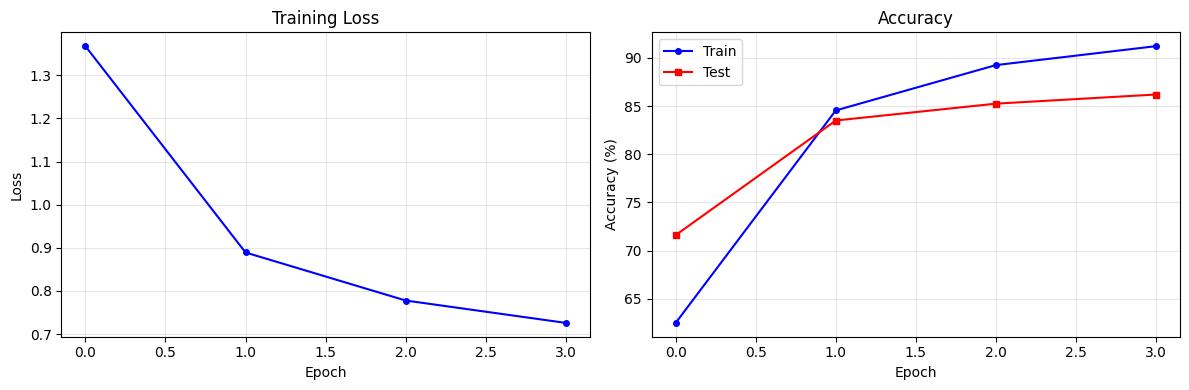

Plot guardado en Drive.


In [6]:
# ─── Celda 6: Visualizar entrenamiento del baseline ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_history['train_loss'], 'b-o', markersize=4)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(train_history['train_acc'], 'b-o', markersize=4, label='Train')
ax2.plot(train_history['test_acc'], 'r-s', markersize=4, label='Test')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/baseline_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot guardado en Drive.")


Calculando Functional Linearity por capa...
(Esto usa el modelo baseline SIN ToFu, como en el paper)


FL Analysis: 100%|██████████| 32/32 [00:10<00:00,  3.20it/s]


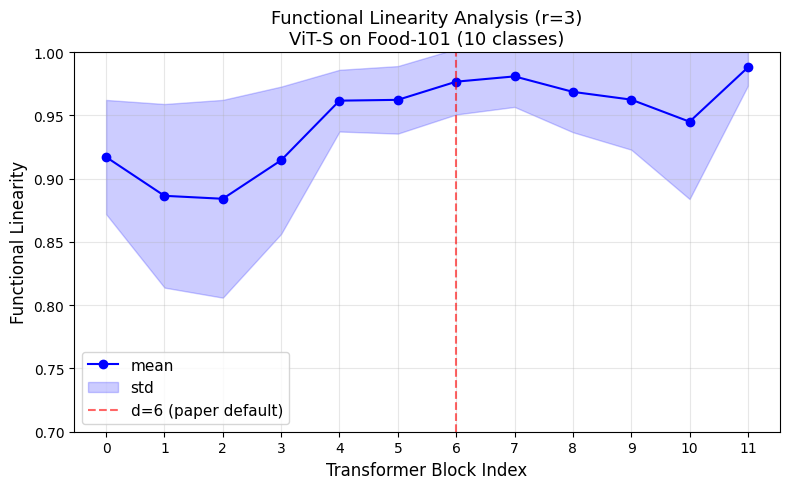


FL por capa:
  Bloque  0: FL = 0.9171 ± 0.0451
  Bloque  1: FL = 0.8864 ± 0.0725
  Bloque  2: FL = 0.8841 ± 0.0782
  Bloque  3: FL = 0.9146 ± 0.0582
  Bloque  4: FL = 0.9617 ± 0.0244
  Bloque  5: FL = 0.9623 ± 0.0267
  Bloque  6: FL = 0.9767 ± 0.0259
  Bloque  7: FL = 0.9808 ± 0.0241
  Bloque  8: FL = 0.9686 ± 0.0319
  Bloque  9: FL = 0.9625 ± 0.0396
  Bloque 10: FL = 0.9450 ± 0.0611
  Bloque 11: FL = 0.9879 ± 0.0145

Sugerencia: d=0 (primera capa con FL ≥ 0.90)
El paper usa d=6 por defecto. Si tu perfil es diferente, ajusta d.


In [7]:
# ─── Celda: Análisis de Linealidad Funcional (Eq. 8 del paper) ───

def compute_functional_linearity(model, dataloader, r=5, n_steps=20, max_batches=50):
    """
    Calcula la Functional Linearity (FL) de cada MLP del ViT,
    según Eq. 8 del paper:

        FL(f, X1, X2) = ||f(X1) - f(X2)||_2 / Σ Δf(t_i)

    donde f es el MLP de cada bloque, y los pares (X1, X2) se
    obtienen del BSM con r pares más similares.
    """
    model.eval()
    num_blocks = len(model.blocks)

    # Acumuladores por bloque
    fl_values = {i: [] for i in range(num_blocks)}

    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(tqdm(dataloader, desc="FL Analysis")):
            if batch_idx >= max_batches:
                break

            images = images.to(device)
            B = images.shape[0]

            # Forward manual capa por capa
            # Patch embedding + CLS + pos_embed
            x = model.patch_embed(images)
            if hasattr(model, 'cls_token'):
                cls_tokens = model.cls_token.expand(B, -1, -1)
                x = torch.cat([cls_tokens, x], dim=1)
            x = x + model.pos_embed
            if hasattr(model, 'pos_drop'):
                x = model.pos_drop(x)

            for block_idx, block in enumerate(model.blocks):
                # ── Pre-atención: obtener keys para BSM ──
                normed = block.norm1(x)
                B_cur, N, C = normed.shape
                head_dim = C // block.attn.num_heads

                qkv = block.attn.qkv(normed).reshape(
                    B_cur, N, 3, block.attn.num_heads, head_dim
                ).permute(2, 0, 3, 1, 4)
                q, k, v = qkv.unbind(0)

                # Keys concatenadas: (B, N, C)
                keys = k.permute(0, 2, 1, 3).reshape(B_cur, N, C)

                # ── Atención completa ──
                attn = (q @ k.transpose(-2, -1)) * block.attn.scale
                attn = attn.softmax(dim=-1)
                attn = block.attn.attn_drop(attn)
                attn_out = (attn @ v).transpose(1, 2).reshape(B_cur, N, C)
                attn_out = block.attn.proj(attn_out)
                attn_out = block.attn.proj_drop(attn_out)

                if hasattr(block, 'ls1'):
                    attn_out = block.ls1(attn_out)
                if hasattr(block, 'drop_path1'):
                    attn_out = block.drop_path1(attn_out)
                x_after_attn = x + attn_out

                # ── BSM sobre tokens espaciales (sin CLS) ──
                keys_spatial = keys[:, 1:, :]
                tokens_spatial = x_after_attn[:, 1:, :]

                n_spatial = tokens_spatial.shape[1]
                n_dst = (n_spatial + 1) // 2
                n_src = n_spatial - n_dst
                r_actual = min(r, n_src)

                if r_actual <= 0:
                    # Avanzar sin medir
                    mlp_out = block.mlp(block.norm2(x_after_attn))
                    if hasattr(block, 'ls2'):
                        mlp_out = block.ls2(mlp_out)
                    if hasattr(block, 'drop_path2'):
                        mlp_out = block.drop_path2(mlp_out)
                    x = x_after_attn + mlp_out
                    continue

                # Encontrar pares similares
                dst_k = F.normalize(keys_spatial[:, :n_dst, :], dim=-1)
                src_k = F.normalize(keys_spatial[:, n_dst:, :], dim=-1)
                sim = torch.bmm(src_k, dst_k.transpose(1, 2))
                max_sim, dst_match = sim.max(dim=-1)
                _, src_top_r = max_sim.topk(r_actual, dim=-1)

                # Obtener pares (X1=src, X2=dst matched)
                batch_idx_t = torch.arange(B_cur, device=device).unsqueeze(1).expand(-1, r_actual)
                X1 = tokens_spatial[:, n_dst:, :][batch_idx_t, src_top_r]  # (B, r, C)
                dst_indices = dst_match.gather(1, src_top_r)               # (B, r)
                X2 = tokens_spatial[:, :n_dst, :][batch_idx_t, dst_indices] # (B, r, C)

                # ── Medir FL del MLP (norm2 + mlp) ──
                def f_mlp(tokens_input):
                    """Aplica norm2 + MLP a tokens individuales."""
                    return block.mlp(block.norm2(tokens_input))

                # f(X1) y f(X2)
                fX1 = f_mlp(X1.reshape(-1, C)).reshape(B_cur, r_actual, -1)
                fX2 = f_mlp(X2.reshape(-1, C)).reshape(B_cur, r_actual, -1)

                # Distancia directa: ||f(X1) - f(X2)||
                direct_dist = (fX1 - fX2).norm(dim=-1)  # (B, r)

                # Distancia a lo largo del camino interpolado
                path_dist = torch.zeros(B_cur, r_actual, device=device)
                dt = 1.0 / (n_steps - 1)

                prev_ft = fX1  # f(X(0)) = f(X1)
                for step in range(1, n_steps):
                    t = step * dt
                    X_t = (1 - t) * X1 + t * X2  # interpolación lineal
                    f_t = f_mlp(X_t.reshape(-1, C)).reshape(B_cur, r_actual, -1)
                    path_dist += (f_t - prev_ft).norm(dim=-1)
                    prev_ft = f_t

                # FL = direct / path  (1.0 = perfectamente lineal)
                fl = direct_dist / path_dist.clamp(min=1e-8)
                fl_values[block_idx].append(fl.cpu())

                # ── Avanzar x al siguiente bloque (forward normal) ──
                mlp_out = block.mlp(block.norm2(x_after_attn))
                if hasattr(block, 'ls2'):
                    mlp_out = block.ls2(mlp_out)
                if hasattr(block, 'drop_path2'):
                    mlp_out = block.drop_path2(mlp_out)
                x = x_after_attn + mlp_out

    # Agregar estadísticas
    stats = {}
    for i in range(num_blocks):
        all_fl = torch.cat(fl_values[i], dim=0).flatten()
        stats[i] = {
            'mean': all_fl.mean().item(),
            'std': all_fl.std().item(),
        }

    return stats


# ── Ejecutar análisis ──
print("Calculando Functional Linearity por capa...")
print("(Esto usa el modelo baseline SIN ToFu, como en el paper)")

# Crear modelo limpio para el análisis
fl_model = create_baseline_model()
fl_model.load_state_dict(baseline_model.state_dict())
fl_model.eval()

fl_stats = compute_functional_linearity(fl_model, test_loader, r=3, n_steps=20, max_batches=50)

del fl_model
torch.cuda.empty_cache()

# ── Plot estilo paper (Fig. 3) ──
blocks = sorted(fl_stats.keys())
means = [fl_stats[i]['mean'] for i in blocks]
stds = [fl_stats[i]['std'] for i in blocks]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(blocks, means, 'b-o', markersize=6, label='mean')
ax.fill_between(blocks,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.2, color='blue', label='std')
ax.set_xlabel('Transformer Block Index', fontsize=12)
ax.set_ylabel('Functional Linearity', fontsize=12)
ax.set_title(f'Functional Linearity Analysis (r=3)\n'
             f'ViT-S on Food-101 ({NUM_CLASSES} classes)', fontsize=13)
ax.set_xticks(blocks)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.7, 1.0)

# Línea punteada en d=6 (valor por defecto del paper)
ax.axvline(x=6, color='red', linestyle='--', alpha=0.6, label='d=6 (paper default)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/functional_linearity.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir valores
print("\nFL por capa:")
for i in blocks:
    print(f"  Bloque {i:2d}: FL = {fl_stats[i]['mean']:.4f} ± {fl_stats[i]['std']:.4f}")

# Sugerir d óptimo
# Buscar el punto donde FL sube consistentemente por encima de ~0.90
suggested_d = 6
for i in blocks:
    if fl_stats[i]['mean'] >= 0.90:
        suggested_d = i
        break
print(f"\nSugerencia: d={suggested_d} (primera capa con FL ≥ 0.90)")
print(f"El paper usa d=6 por defecto. Si tu perfil es diferente, ajusta d.")

## 3. Implementación de Token Fusion (ToFu)

Según el paper, Token Fusion consta de:
1. **Bipartite Soft Matching (BSM):** Particiona los tokens en dos conjuntos (SRC, DST) y encuentra los `r` pares más similares.
2. **Tres estrategias de fusión:**
   - **Pruned Merging:** Descarta los tokens SRC seleccionados (rápido, sin interpolación).
   - **Average Merging:** Promedia los tokens SRC en sus DST correspondientes.
   - **MLERP Merging:** Como Average pero preservando la norma máxima (evita distributional shift).
3. **Hybrid Merging:** Usa Pruned en capas tempranas (l < d) y MLERP en capas tardías (l ≥ d), ya que las capas tempranas tienen menor "functional linearity".
4. **Posición:** La reducción R se aplica **entre la capa de Atención y el MLP**, no antes del bloque completo.


In [8]:
# ─── Celda 7: Implementación del algoritmo ToFu ───

def bipartite_soft_matching(metric, r):
    """
    Bipartite Soft Matching (BSM) del paper ToMe/ToFu.
    Particiona tokens en dos conjuntos y encuentra los r pares más similares.

    Args:
        metric: (B, N, C) — scores de similitud (attention keys del paper)
        r: número de tokens a reducir

    Returns:
        n_dst, n_src: tamaños de los conjuntos
        src_top_r: (B, r) índices de los src tokens a fusionar
        dst_match: (B, n_src) índice del dst más similar para cada src
    """
    B, N, C = metric.shape

    # Particionar: primera mitad → DST, segunda mitad → SRC
    n_dst = (N + 1) // 2  # ceil  → primera mitad = DST
    n_src = N - n_dst    # segunda mitad = SRC

    dst_m = metric[:, :n_dst, :]   # (B, n_dst, C)
    src_m = metric[:, n_dst:, :]   # (B, n_src, C)

    # Similitud coseno entre cada src y cada dst
    dst_n = F.normalize(dst_m, dim=-1)
    src_n = F.normalize(src_m, dim=-1)
    sim   = torch.bmm(src_n, dst_n.transpose(1, 2))  # (B, n_src, n_dst)

    # Máximo dst para cada src
    max_sim, dst_match = sim.max(dim=-1)  # (B, n_src)

    # Top-r src con mayor similitud al su dst más cercano
    r = min(r, n_src)  # no podemos remover más tokens que los que hay en src
    _, src_top_r = max_sim.topk(r, dim=-1)  # (B, r)

    return n_dst, n_src, src_top_r, dst_match


class ToFuReduce(nn.Module):
    """
    Módulo de reducción Token Fusion.
    Implementa Algorithm 1 del paper con las 3 estrategias + hybrid.
    """
    def __init__(self, r, method='hybrid', d=6, layer_idx=0):
        super().__init__()
        self.r = r            # tokens a reducir por capa
        self.method = method  # 'prune', 'average', 'mlerp', 'hybrid'
        self.d = d            # profundidad de transición para hybrid
        self.layer_idx = layer_idx

    def forward(self, x, metric=None):
        """
        Args:
            x      : (B, N, C)  tokens con CLS en pos 0
            metric : (B, N, C)  attention keys con CLS en pos 0
                                Si None, se usa x (fallback)
        Returns:
            x_reduced: (B, N-r, C)
        """
        # ── Fallback: si no vienen keys se usa x (menos preciso) ──
        if metric is None:
            metric = x

        B, N, C = x.shape
        cls_token = x[:, 0:1, :]     # (B, 1, C)
        tokens = x[:, 1:, :]         # (B, N-1, C) tokens espaciales
        # Separar también las keys (excluir CLS)
        metric_spatial = metric[:, 1:, :]   # (B, N-1, C_key)

        n_spatial = tokens.shape[1]

        r = min(self.r, n_spatial // 2 - 1)
        if r <= 0:
            return x

        # Estrategia para esta capa (hybrid → prune early / mlerp late)
        if self.method == 'hybrid':
            current_method = 'prune' if self.layer_idx < self.d else 'mlerp'
        else:
            current_method = self.method

        # ── BSM sobre las KEYS (no sobre x) ───
        n_dst, n_src, src_top_r, dst_match = bipartite_soft_matching(metric_spatial, r)

        # Dividir tokens x en DST y SRC con el mismo particionado
        dst_tokens = tokens[:, :n_dst, :]   # (B, n_dst, C)
        src_tokens = tokens[:, n_dst:, :]   # (B, n_src, C)

        # Tokens SRC que NO se fusionan (se conservan tal cual)
        keep_mask = torch.ones(B, n_src, dtype=torch.bool, device=x.device)
        keep_mask.scatter_(1, src_top_r, False)
        unc_tokens = src_tokens[keep_mask].view(B, n_src - r, C)

        if current_method == 'prune':
            # ── Pruned Merging: descartar src seleccionados ──
            new_tokens = torch.cat([dst_tokens, unc_tokens], dim=1)

        elif current_method in ('average', 'mlerp'):
            # ── Average / MLERP Merging ──
            batch_idx      = torch.arange(B, device=x.device).unsqueeze(1).expand(-1, r)
            src_to_merge   = src_tokens[batch_idx, src_top_r]        # (B, r, C)
            dst_indices    = dst_match.gather(1, src_top_r)           # (B, r)

            merged_dst = dst_tokens.clone()
            counts     = torch.ones(B, n_dst, 1, device=x.device)

            dst_idx_C = dst_indices.unsqueeze(-1).expand(-1, -1, C)  # (B, r, C)
            merged_dst.scatter_add_(1, dst_idx_C, src_to_merge)

            dst_idx_1 = dst_indices.unsqueeze(-1)                     # (B, r, 1)
            counts.scatter_add_(1, dst_idx_1, torch.ones(B, r, 1, device=x.device))

            merged_dst = merged_dst / counts   # promedio

            if current_method == 'mlerp':
                # ── MLERP: reescalar con la norma máxima (Eq. 10) ──
                dst_norms = dst_tokens.norm(dim=-1, keepdim=True)     # (B, n_dst, 1)
                src_norms = src_to_merge.norm(dim=-1, keepdim=True)   # (B, r, 1)

                max_norms = dst_norms.clone()
                max_norms.scatter_reduce_(
                    1, dst_idx_1, src_norms, reduce='amax', include_self=True
                )

                merged_norm = merged_dst.norm(dim=-1, keepdim=True).clamp(min=1e-8)
                merged_dst  = (merged_dst / merged_norm) * max_norms

            new_tokens = torch.cat([merged_dst, unc_tokens], dim=1)

        return torch.cat([cls_token, new_tokens], dim=1)


print("✓ ToFuReduce (BSM sobre attention keys) implementado.")


✓ ToFuReduce (BSM sobre attention keys) implementado.


In [9]:
# ─── Celda 8: Función para inyectar ToFu en el modelo ViT ───

def attn_forward_with_keys(attn_module, x):
    """
    Ejecuta la atención completa Y retorna las keys,
    con un solo cómputo de QKV.
    """
    B, N, C = x.shape
    head_dim = C // attn_module.num_heads

    # ── UN solo cómputo de QKV ──
    qkv = attn_module.qkv(x).reshape(
        B, N, 3, attn_module.num_heads, head_dim
    ).permute(2, 0, 3, 1, 4)          # (3, B, heads, N, head_dim)
    q, k, v = qkv.unbind(0)

    # Keys para BSM: (B, heads, N, head_dim) → (B, N, C)
    keys = k.permute(0, 2, 1, 3).reshape(B, N, C).detach()

    # ── Atención ──
    attn = (q @ k.transpose(-2, -1)) * attn_module.scale
    attn = attn.softmax(dim=-1)
    attn = attn_module.attn_drop(attn)

    out = (attn @ v).transpose(1, 2).reshape(B, N, C)
    out = attn_module.proj(out)
    out = attn_module.proj_drop(out)

    return out, keys


def apply_tofu_to_model(model, r, method='hybrid', d=6):
    """
    Inyecta ToFu en cada bloque del ViT.
    FIX: QKV se computa UNA sola vez por bloque.
    """
    for idx, block in enumerate(model.blocks):
        tofu = ToFuReduce(r=r, method=method, d=d, layer_idx=idx)

        def make_new_forward(blk, tofu_mod):
            def new_forward(x):
                # 1) Norm + Atención (QKV se computa una sola vez)
                normed = blk.norm1(x)
                attn_out, keys = attn_forward_with_keys(blk.attn, normed)

                if hasattr(blk, 'ls1'):
                    attn_out = blk.ls1(attn_out)
                if hasattr(blk, 'drop_path1'):
                    attn_out = blk.drop_path1(attn_out)
                x = x + attn_out

                # 2) Token Fusion — usa keys como métrica para BSM
                x = tofu_mod(x, metric=keys)

                # 3) MLP
                mlp_out = blk.mlp(blk.norm2(x))
                if hasattr(blk, 'ls2'):
                    mlp_out = blk.ls2(mlp_out)
                if hasattr(blk, 'drop_path2'):
                    mlp_out = blk.drop_path2(mlp_out)
                x = x + mlp_out
                return x

            return new_forward

        block.forward = make_new_forward(block, tofu)
        block._tofu_module = tofu

    return model.to(device)


def create_tofu_model(baseline_state_dict, r, method='hybrid', d=6):
    model = create_baseline_model()
    model.load_state_dict(baseline_state_dict)
    model = apply_tofu_to_model(model, r=r, method=method, d=d)
    model.eval()
    return model


# ── Verificación ──
print("Verificando implementación de ToFu (con attention keys)...")
test_model = create_tofu_model(baseline_model.state_dict(), r=4, method='hybrid', d=6)
images_v, labels_v = next(iter(test_loader))
with torch.no_grad():
    output_v = test_model(images_v.to(device))
print(f"  Input:  {images_v.shape}")
print(f"  Output: {output_v.shape}  (esperado: [B, {NUM_CLASSES}])")

test_acc_v = evaluate_model(test_model, test_loader)
print(f"  Accuracy ToFu (r=4, hybrid, d=6): {test_acc_v:.2f}%  |  Baseline: {baseline_acc:.2f}%")
del test_model
print("✓ Verificación exitosa.")



Verificando implementación de ToFu (con attention keys)...
  Input:  torch.Size([64, 3, 224, 224])
  Output: torch.Size([64, 10])  (esperado: [B, 10])
  Accuracy ToFu (r=4, hybrid, d=6): 83.10%  |  Baseline: 86.20%
✓ Verificación exitosa.


## 4. Medición de FLOPs y Latencia


In [10]:
# ─── Celda 9: Funciones de medición de eficiencia ───

def count_flops(model, input_size=(1, 3, 224, 224)):
    """Calcula FLOPs del modelo (solo funciona con modelos sin ToFu)."""
    model.eval()
    inputs = torch.randn(input_size).to(device)
    try:
        flops = FlopCountAnalysis(model, inputs)
        flops.unsupported_ops_warnings(False)
        flops.uncalled_modules_warnings(False)
        return flops.total()
    except Exception:
        return None

def estimate_tofu_flops(baseline_flops, r, num_blocks=12, num_patches=196):
    total_patches   = num_patches
    flops_per_block = baseline_flops / num_blocks
    estimated_flops = 0.0
    for _ in range(num_blocks):
        ratio = total_patches / num_patches
        estimated_flops += flops_per_block * (ratio ** 1.5)
        total_patches = max(total_patches - r, r)
    return estimated_flops

def measure_throughput(model, batch_size=64, input_size=(3, 224, 224), n_runs=30):
    model.eval()
    inputs = torch.randn(batch_size, *input_size).to(device)
    for _ in range(5):
        with torch.no_grad():
            _ = model(inputs)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    times = []
    for _ in range(n_runs):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            _ = model(inputs)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.time() - t0)

    avg_t = np.mean(times)
    std_t = np.std(times)
    return batch_size / avg_t, avg_t * 1000, std_t * 1000   # throughput, mean_ms, std_ms

baseline_flops_model = create_baseline_model()
baseline_flops_model.load_state_dict(baseline_model.state_dict())
baseline_flops_model.eval()

baseline_flops = count_flops(baseline_flops_model)
baseline_throughput, baseline_lat_mean, baseline_lat_std = measure_throughput(baseline_flops_model)

print(f"Baseline FLOPs:      {baseline_flops/1e9:.3f} GFLOPs")
print(f"Baseline Throughput: {baseline_throughput:.1f} imgs/sec")
print(f"Baseline Latencia:   {baseline_lat_mean:.2f} ± {baseline_lat_std:.2f} ms (batch=64)")
del baseline_flops_model

Baseline FLOPs:      4.250 GFLOPs
Baseline Throughput: 292.6 imgs/sec
Baseline Latencia:   218.73 ± 1.46 ms (batch=64)


## 5. Grid Search de Hiperparámetros

Según el paper, los hiperparámetros clave son:
- **r:** Número de tokens a reducir por capa (controla el trade-off eficiencia/accuracy)
- **d:** Capa de transición entre PRUNE y AVG/MLERP (paper recomienda d=6)
- **method:** Estrategia de fusión (prune, average, mlerp, hybrid)


In [11]:
# ─── Celda 10: Grid Search de Hiperparámetros ───

r_values = [3, 6, 9, 12, 15] #3, 6, 9, 12, 15
d_values = [1, 4, 7, 10] #1, 4, 7, 10
methods = ['prune', 'average', 'mlerp', 'hybrid']  #'prune', 'average', 'mlerp', 'hybrid'

results = []
baseline_state = baseline_model.state_dict()

configs = []
for r in r_values:
    for method in methods:
      if method == "hybrid":
          for d in d_values:
            configs.append((r, d, method)) # solo en este metodo importa la variacion en "d"
      else:
        configs.append((r, 6, method))

total_configs = len(configs)
print(f"Ejecutando grid search: {total_configs} configuraciones")
print(f"r={r_values}, d={d_values}, methods={methods}")
print("="*70)

for i, (r, d, method) in enumerate(configs):
    config_label = f"r={r}, d={d}, method={method}"
    print(f"[{i+1}/{total_configs}] {config_label}", end=" → ")

    try:
        tofu_model = create_tofu_model(baseline_state, r=r, method=method, d=d)

        acc = evaluate_model(tofu_model, test_loader)
        throughput, lat_mean, lat_std = measure_throughput(tofu_model, batch_size=64, n_runs=20)
        speedup = throughput / baseline_throughput

        # Tokens restantes tras 12 capas (teórico, sin caer por debajo de r)
        tokens_remaining = max(196 - r * 12, r)
        token_reduction_pct = (1 - tokens_remaining / 196) * 100

        results.append({
            'r': r, 'd': d, 'method': method,
            'accuracy': acc,
            'acc_drop': baseline_acc - acc,
            'token_reduction_pct': token_reduction_pct,
            'throughput_imgs_sec': throughput,
            'latency_batch_ms': lat_mean,
            'speedup': speedup,
        })

        print(f"Acc={acc:.2f}% (Δ={baseline_acc-acc:+.2f}%), "
              f"Tokens↓≈{token_reduction_pct:.0f}%, "
              f"{throughput:.0f} imgs/s ({speedup:.2f}x)")

        del tofu_model
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"ERROR: {e}")
        results.append({
            'r': r, 'd': d, 'method': method,
            'accuracy': None, 'acc_drop': None,
            'token_reduction_pct': None,
            'throughput_imgs_sec': None, 'latency_batch_ms': None,
            'speedup': None,
        })

print("\n" + "="*70)
print("Grid search completado.")


Ejecutando grid search: 35 configuraciones
r=[3, 6, 9, 12, 15], d=[1, 4, 7, 10], methods=['prune', 'average', 'mlerp', 'hybrid']
[1/35] r=3, d=6, method=prune → Acc=83.75% (Δ=+2.45%), Tokens↓≈18%, 276 imgs/s (0.94x)
[2/35] r=3, d=6, method=average → Acc=83.90% (Δ=+2.30%), Tokens↓≈18%, 275 imgs/s (0.94x)
[3/35] r=3, d=6, method=mlerp → Acc=83.70% (Δ=+2.50%), Tokens↓≈18%, 275 imgs/s (0.94x)
[4/35] r=3, d=1, method=hybrid → Acc=84.20% (Δ=+2.00%), Tokens↓≈18%, 276 imgs/s (0.94x)
[5/35] r=3, d=4, method=hybrid → Acc=83.85% (Δ=+2.35%), Tokens↓≈18%, 277 imgs/s (0.95x)
[6/35] r=3, d=7, method=hybrid → Acc=83.85% (Δ=+2.35%), Tokens↓≈18%, 278 imgs/s (0.95x)
[7/35] r=3, d=10, method=hybrid → Acc=83.75% (Δ=+2.45%), Tokens↓≈18%, 277 imgs/s (0.95x)
[8/35] r=6, d=6, method=prune → Acc=80.25% (Δ=+5.95%), Tokens↓≈37%, 309 imgs/s (1.06x)
[9/35] r=6, d=6, method=average → Acc=81.00% (Δ=+5.20%), Tokens↓≈37%, 308 imgs/s (1.05x)
[10/35] r=6, d=6, method=mlerp → Acc=81.20% (Δ=+5.00%), Tokens↓≈37%, 305 imgs/s

In [12]:
# ─── Celda 11: Tabla de resultados ───
df_results = pd.DataFrame(results)

baseline_row = pd.DataFrame([{
    'r': 0, 'd': '-', 'method': 'baseline',
    'accuracy': baseline_acc, 'acc_drop': 0,
    'token_reduction_pct': 0,
    'throughput_imgs_sec': baseline_throughput,
    'latency_batch_ms': baseline_lat_mean,
    'speedup': 1.0,
}])
df_all = pd.concat([baseline_row, df_results], ignore_index=True)

display_cols = ['method', 'r', 'd', 'accuracy', 'acc_drop',
                'token_reduction_pct', 'throughput_imgs_sec', 'speedup']

print("Top 20 configuraciones por Accuracy:")
print("="*100)
print(df_all.sort_values('accuracy', ascending=False).head(20)[display_cols].to_string(index=False))

# Punto de crossover de speedup
df_valid = df_results.dropna(subset=['accuracy'])
df_fast = df_valid[df_valid['speedup'] > 1.0]
if len(df_fast) > 0:
    print(f"\n✓ Speedup real (>1.0x) alcanzado desde r={int(df_fast['r'].min())}")
    best_fast = df_fast.sort_values('accuracy', ascending=False).iloc[0]
    print(f"  Mejor con speedup: method={best_fast['method']}, r={int(best_fast['r'])}, "
          f"d={int(best_fast['d'])}, Acc={best_fast['accuracy']:.2f}%, "
          f"speedup={best_fast['speedup']:.2f}x")
else:
    print(f"\n✗ Ninguna configuración logró speedup >1.0x sobre el baseline")

df_all.to_csv(f'{RESULTS_DIR}/grid_search_results.csv', index=False)
print(f"\nResultados guardados en: {RESULTS_DIR}/grid_search_results.csv")



Top 20 configuraciones por Accuracy:
  method  r  d  accuracy  acc_drop  token_reduction_pct  throughput_imgs_sec  speedup
baseline  0  -     86.20      0.00             0.000000           292.604808 1.000000
  hybrid  3  1     84.20      2.00            18.367347           275.661424 0.942095
 average  3  6     83.90      2.30            18.367347           274.820414 0.939220
  hybrid  3  4     83.85      2.35            18.367347           276.947721 0.946491
  hybrid  3  7     83.85      2.35            18.367347           278.123945 0.950511
   prune  3  6     83.75      2.45            18.367347           275.744604 0.942379
  hybrid  3 10     83.75      2.45            18.367347           276.617284 0.945361
   mlerp  3  6     83.70      2.50            18.367347           275.092009 0.940149
   mlerp  6  6     81.20      5.00            36.734694           305.115547 1.042756
  hybrid  6  7     81.20      5.00            36.734694           309.179965 1.056647
  hybrid  6  4   

In [13]:
# ─── Celda: Métricas detalladas — Accuracy, Precision, Recall, F1-Score ───
from sklearn.metrics import classification_report, confusion_matrix

def get_predictions(model, loader):
    """Obtiene todas las predicciones y etiquetas reales del loader."""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

# ── Identificar las 2 mejores configs ToFu ──
best_acc_cfg = df_valid.sort_values('accuracy', ascending=False).iloc[0]
best_spd_cfg = df_valid.sort_values('speedup', ascending=False).iloc[0]

# ── Definir los 3 modelos a evaluar ──
models_to_eval = {}

# 1) Baseline finetuneado
models_to_eval['Baseline (finetuned)'] = baseline_model

# 2) ToFu — Mejor Accuracy
r_acc, d_acc, m_acc = int(best_acc_cfg['r']), int(best_acc_cfg['d']), best_acc_cfg['method']
models_to_eval[f'ToFu Mejor Acc (r={r_acc}, d={d_acc}, {m_acc})'] = \
    create_tofu_model(baseline_model.state_dict(), r=r_acc, method=m_acc, d=d_acc)

# 3) ToFu — Mejor Speedup
r_spd, d_spd, m_spd = int(best_spd_cfg['r']), int(best_spd_cfg['d']), best_spd_cfg['method']
models_to_eval[f'ToFu Mejor Speedup (r={r_spd}, d={d_spd}, {m_spd})'] = \
    create_tofu_model(baseline_model.state_dict(), r=r_spd, method=m_spd, d=d_spd)

# ── Evaluar cada modelo ──
all_reports = {}

for name, model in models_to_eval.items():
    print("=" * 70)
    print(f"  {name}")
    print("=" * 70)

    y_true, y_pred = get_predictions(model, test_loader)

    report_str = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
    print(report_str)

    # Guardar report como dict para tabla comparativa
    all_reports[name] = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

# ── Tabla comparativa resumen ──
print("\n" + "=" * 70)
print("  TABLA COMPARATIVA — Métricas Globales (weighted avg)")
print("=" * 70)

summary_rows = []
for name, report in all_reports.items():
    w = report['weighted avg']
    summary_rows.append({
        'Modelo': name,
        'Accuracy': f"{report['accuracy']:.4f}",
        'Precision': f"{w['precision']:.4f}",
        'Recall': f"{w['recall']:.4f}",
        'F1-Score': f"{w['f1-score']:.4f}",
    })

df_metrics = pd.DataFrame(summary_rows)
print(df_metrics.to_string(index=False))

# ── Guardar en Drive ──
# 1) Tabla comparativa global
df_metrics.to_csv(f'{RESULTS_DIR}/metrics_summary.csv', index=False)

# 2) Reportes detallados por clase (un CSV con todas las métricas)
detailed_rows = []
for model_name, report in all_reports.items():
    for class_label, metrics in report.items():
        if isinstance(metrics, dict):  # saltar 'accuracy' (es float)
            detailed_rows.append({
                'Modelo': model_name,
                'Clase': class_label,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1-Score': metrics['f1-score'],
                'Support': metrics['support'],
            })
    # Agregar accuracy como fila separada
    detailed_rows.append({
        'Modelo': model_name,
        'Clase': 'accuracy',
        'Precision': report['accuracy'],
        'Recall': report['accuracy'],
        'F1-Score': report['accuracy'],
        'Support': report['weighted avg']['support'],
    })

df_detailed = pd.DataFrame(detailed_rows)
df_detailed.to_csv(f'{RESULTS_DIR}/metrics_detailed_per_class.csv', index=False)

print(f"\n✓ Métricas guardadas en Drive:")
print(f"  - {RESULTS_DIR}/metrics_summary.csv")
print(f"  - {RESULTS_DIR}/metrics_detailed_per_class.csv")

# ── Limpiar modelos ToFu de memoria ──
for name in list(models_to_eval.keys()):
    if name != 'Baseline (finetuned)':
        del models_to_eval[name]
torch.cuda.empty_cache()



  Baseline (finetuned)
              precision    recall  f1-score   support

           0     0.9459    0.8750    0.9091       200
           1     0.9043    0.8500    0.8763       200
           2     0.9037    0.8450    0.8734       200
           3     0.7857    0.7700    0.7778       200
           4     0.9050    0.9050    0.9050       200
           5     0.8808    0.8500    0.8651       200
           6     0.8757    0.7750    0.8223       200
           7     0.8846    0.9200    0.9020       200
           8     0.7449    0.9050    0.8172       200
           9     0.8296    0.9250    0.8747       200

    accuracy                         0.8620      2000
   macro avg     0.8660    0.8620    0.8623      2000
weighted avg     0.8660    0.8620    0.8623      2000

  ToFu Mejor Acc (r=3, d=1, hybrid)
              precision    recall  f1-score   support

           0     0.9314    0.8150    0.8693       200
           1     0.9341    0.7800    0.8501       200
           2     0.

## 6. Visualización de Resultados


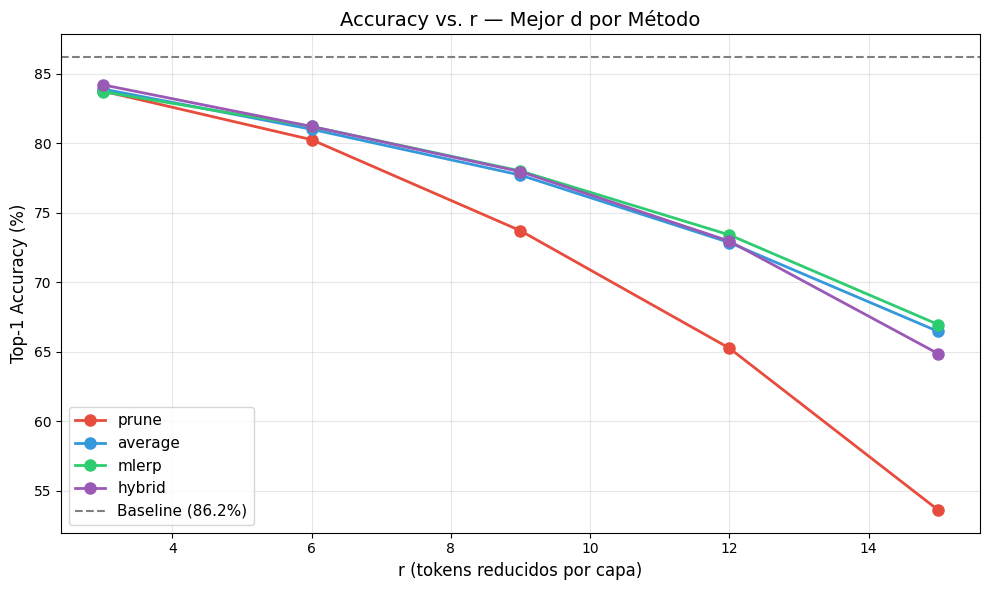

In [14]:
# ─── Celda 12: Plot 1 — Accuracy vs r por método (mejor d por método) ───
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'prune': '#e74c3c', 'average': '#3498db', 'mlerp': '#2ecc71', 'hybrid': '#9b59b6'}

for method in methods:
    subset = df_valid[df_valid['method'] == method]
    # Para cada r, tomar la mejor d (max accuracy)
    best_per_r = subset.loc[subset.groupby('r')['accuracy'].idxmax()].sort_values('r')
    if len(best_per_r) > 0:
        ax.plot(best_per_r['r'], best_per_r['accuracy'], '-o',
                color=colors[method], label=method, linewidth=2, markersize=8)

ax.axhline(y=baseline_acc, color='gray', linestyle='--', linewidth=1.5,
           label=f'Baseline ({baseline_acc:.1f}%)')
ax.set_xlabel('r (tokens reducidos por capa)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs. r — Mejor d por Método', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/accuracy_vs_r_best_d.png', dpi=150, bbox_inches='tight')
plt.show()



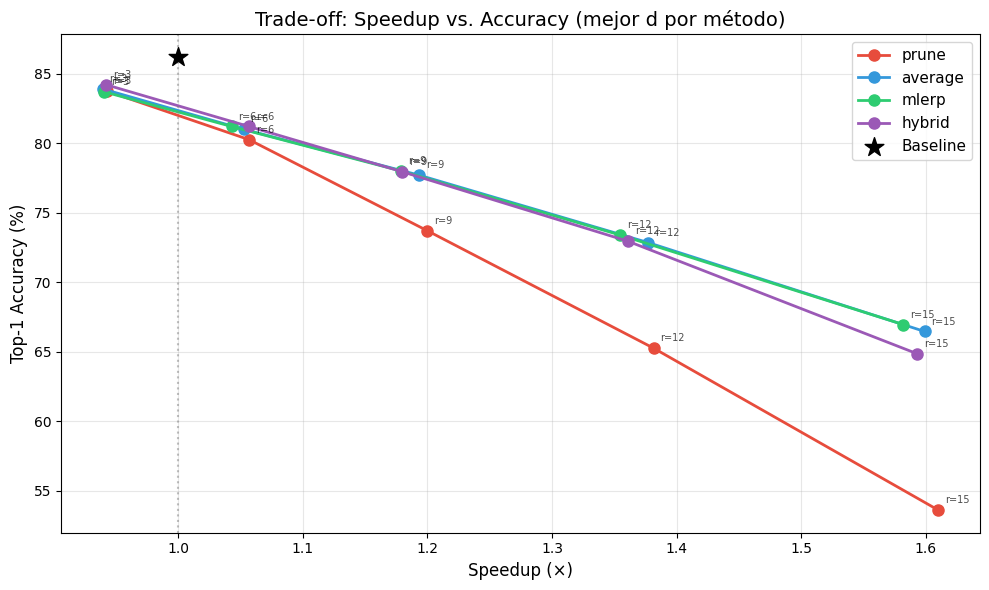

In [15]:
# ─── Celda 13: Plot 2 — Speedup vs Accuracy (Pareto) ───
fig, ax = plt.subplots(figsize=(10, 6))

for method in methods:
    subset = df_valid[df_valid['method'] == method]
    best_per_r = subset.loc[subset.groupby('r')['accuracy'].idxmax()].sort_values('r')
    if len(best_per_r) > 0:
        ax.plot(best_per_r['speedup'], best_per_r['accuracy'], '-o',
                color=colors[method], label=method, linewidth=2, markersize=8)
        for _, row in best_per_r.iterrows():
            ax.annotate(f"r={int(row['r'])}",
                        (row['speedup'], row['accuracy']),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7, alpha=0.7)

ax.scatter(1.0, baseline_acc, color='black', s=200, marker='*',
           zorder=5, label='Baseline', edgecolors='black')
ax.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Speedup (×)', fontsize=12)
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12)
ax.set_title('Trade-off: Speedup vs. Accuracy (mejor d por método)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/speedup_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

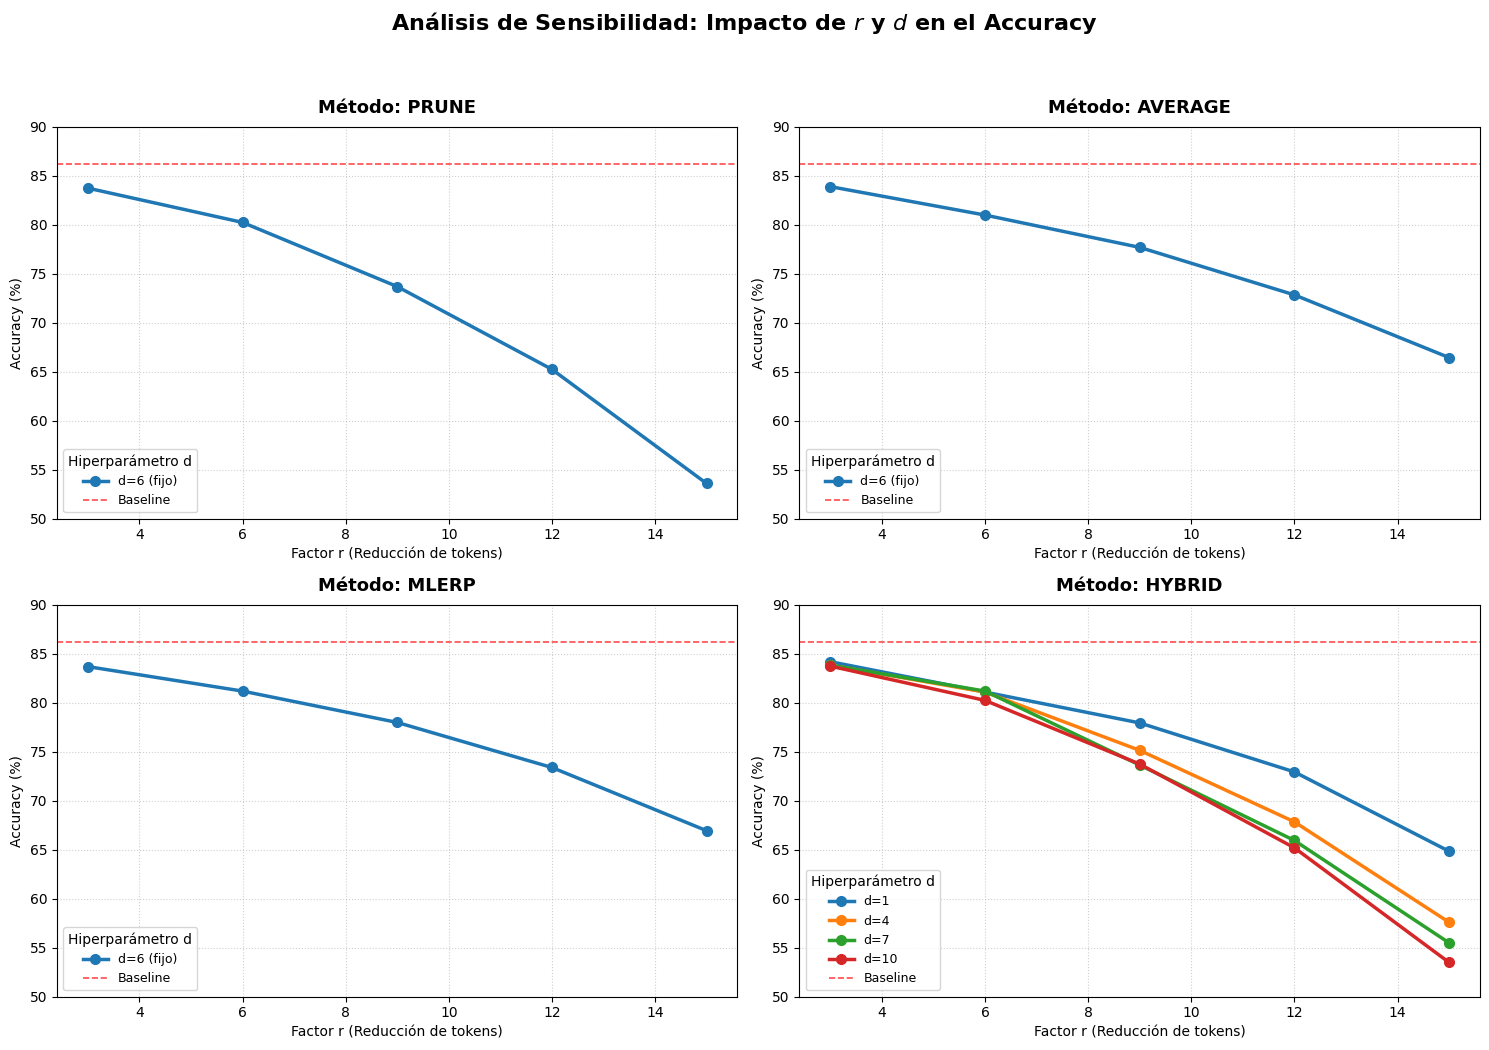

In [16]:
# ─── Celda 14: Plot 3 — Ablación de d (Dinámico) ───
import matplotlib.pyplot as plt

# Creamos la figura
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

# Aseguramos que usamos los métodos que realmente están en el dataframe
available_methods = df_valid['method'].unique()

for ax_idx, method in enumerate(methods):
    ax = axes[ax_idx]
    # Filtrar datos para el método actual
    subset = df_valid[df_valid['method'] == method]

    if subset.empty:
        ax.text(0.5, 0.5, f"No hay datos para {method}", ha='center')
        continue

    # CAMBIO CLAVE: Iterar sobre los valores de 'd' que REALMENTE existen en los datos
    actual_d_present = sorted(subset['d'].unique())

    for d_val in actual_d_present:
        sub_d = subset[subset['d'] == d_val].sort_values('r')

        # Etiqueta descriptiva
        label_text = f'd={d_val}'
        if method != 'hybrid':
            label_text += " (fijo)"

        ax.plot(sub_d['r'], sub_d['accuracy'], '-o',
                label=label_text, linewidth=2.5, markersize=7)

    # Dibujar la línea del Baseline
    ax.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Baseline')

    # Configuración de ejes
    ax.set_title(f'Método: {method.upper()}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Factor r (Reducción de tokens)', fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(title="Hiperparámetro d", fontsize=9, title_fontsize=10)

    # Ajustar el límite inferior para ver mejor la degradación
    current_min = subset['accuracy'].min()
    ax.set_ylim(50, 90)

# Título global
plt.suptitle('Análisis de Sensibilidad: Impacto de $r$ y $d$ en el Accuracy',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para el título superior

# Guardar con alta calidad
import os
os.makedirs(f'{RESULTS_DIR}/plots', exist_ok=True)
plt.savefig(f'{RESULTS_DIR}/plots/ablation_d_all_methods.png', dpi=200, bbox_inches='tight')
plt.show()

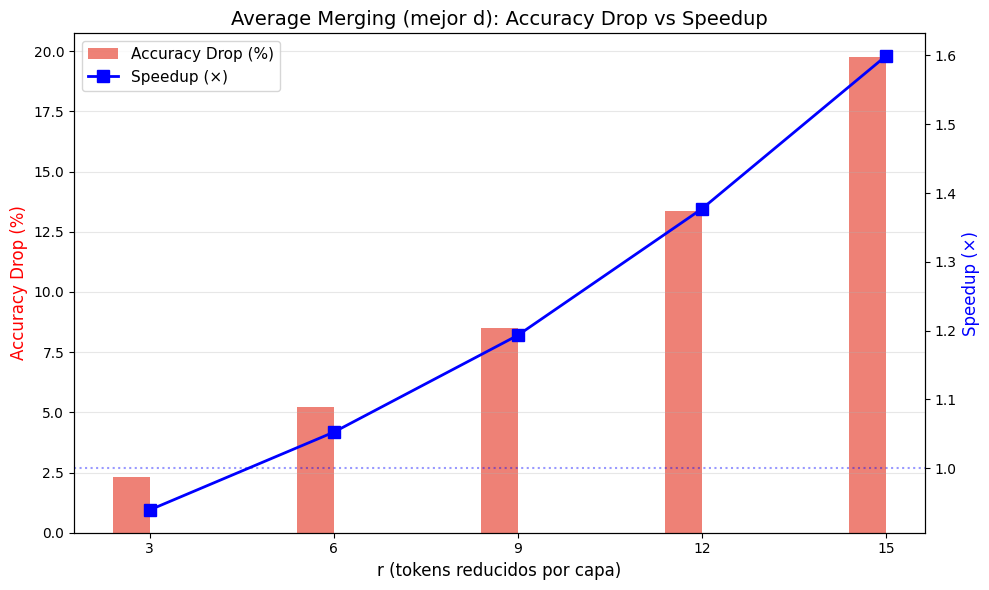

In [17]:
# ─── Celda 15: Plot 4 — Speedup y Acc Drop vs r (average, mejor d) ───
# Tomar el mejor d por cada r para average
df_avg = df_valid[df_valid['method'] == 'average']
df_avg_best = df_avg.loc[df_avg.groupby('r')['accuracy'].idxmax()].sort_values('r')

if len(df_avg_best) > 0:
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    ax1.bar(df_avg_best['r'] - 0.3, df_avg_best['acc_drop'], width=0.6,
            color='#e74c3c', alpha=0.7, label='Accuracy Drop (%)')
    ax2.plot(df_avg_best['r'], df_avg_best['speedup'], 'b-s', linewidth=2,
             markersize=8, label='Speedup (×)')
    ax2.axhline(y=1.0, color='blue', linestyle=':', alpha=0.4)

    ax1.set_xlabel('r (tokens reducidos por capa)', fontsize=12)
    ax1.set_ylabel('Accuracy Drop (%)', fontsize=12, color='red')
    ax2.set_ylabel('Speedup (×)', fontsize=12, color='blue')
    ax1.set_title('Average Merging (mejor d): Accuracy Drop vs Speedup', fontsize=14)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left')

    ax1.set_xticks(df_avg_best['r'].values)
    ax1.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/plots/tradeoff_avg.png', dpi=150, bbox_inches='tight')
    plt.show()


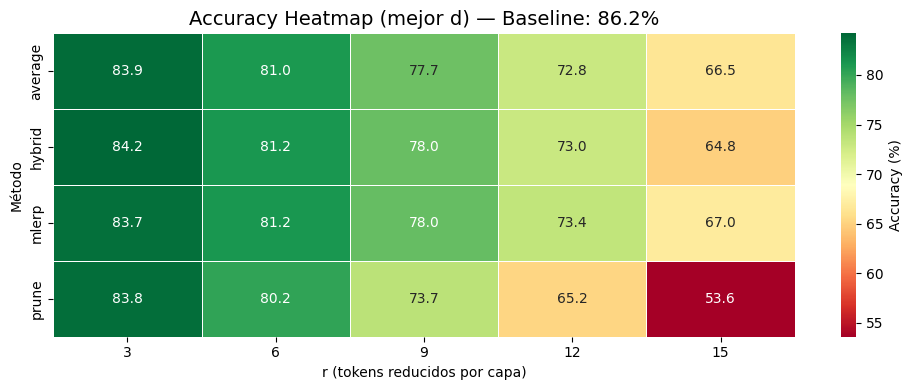

In [18]:
# ─── Celda 16: Plot 5 — Heatmap de accuracy (r vs method, mejor d) ───
# Para el heatmap, usar la mejor d de cada combinación (r, method)
df_best_d = df_valid.loc[df_valid.groupby(['method', 'r'])['accuracy'].idxmax()]
df_heat = df_best_d.pivot_table(index='method', columns='r', values='accuracy')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_heat, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Accuracy (%)'})
ax.set_title(f'Accuracy Heatmap (mejor d) — Baseline: {baseline_acc:.1f}%', fontsize=14)
ax.set_xlabel('r (tokens reducidos por capa)')
ax.set_ylabel('Método')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/heatmap_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Ejemplos de Clasificación
Visualizamos predicciones del modelo baseline vs. el mejor modelo ToFu.


Config mayor accuracy:  method=hybrid, r=3, d=1, Acc=84.20%, speedup=0.94x
Config mayor speedup:   method=prune, r=15, d=6, Acc=53.60%, speedup=1.61x


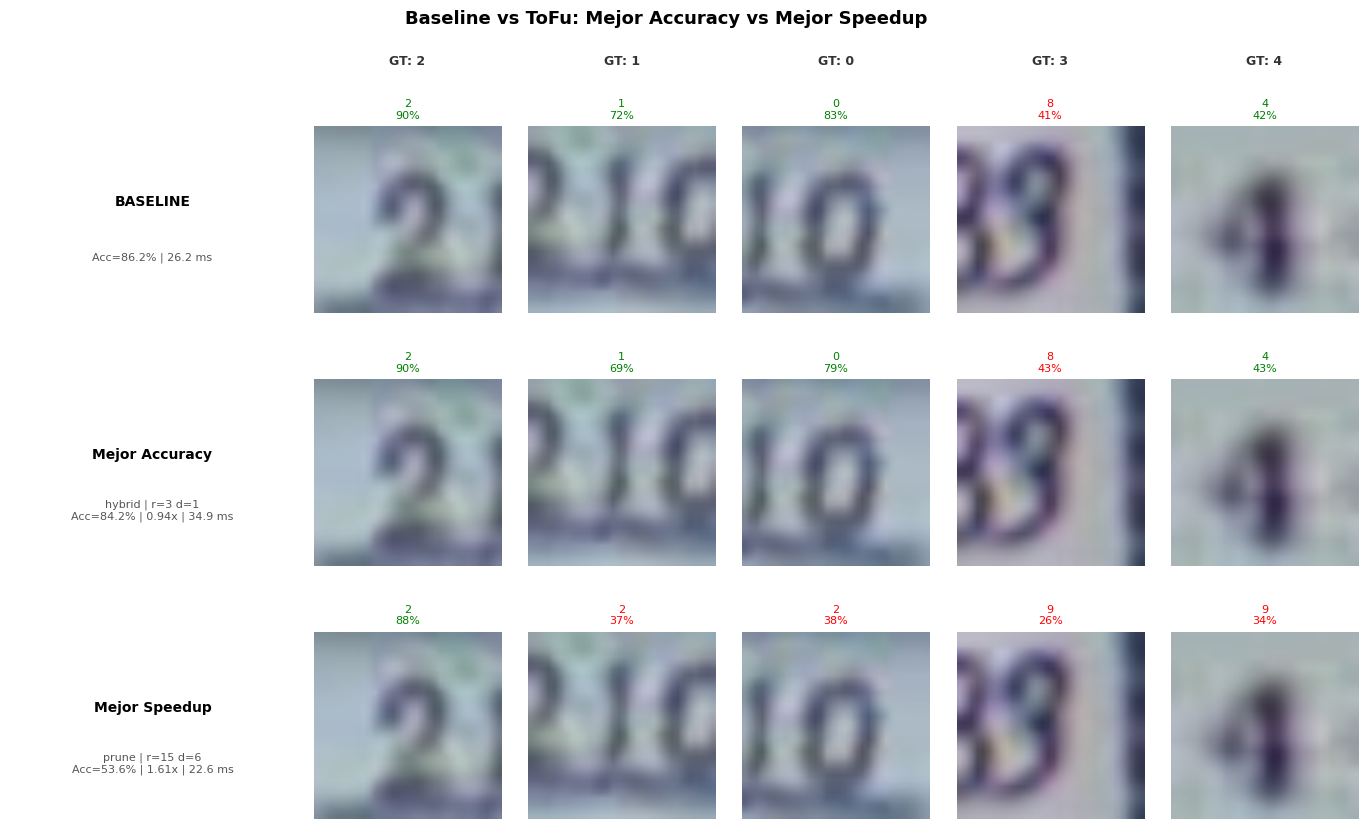

In [19]:
# ─── Celda 17: Ejemplos de clasificación con imágenes ───

inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# ── Seleccionar 1 imagen por clase (hasta 5 clases) ──
n_classes_show = min(NUM_CLASSES, 5)
sample_images = []
sample_labels = []
classes_found = set()

for images_batch, labels_batch in test_loader:
    for j in range(images_batch.size(0)):
        lbl = labels_batch[j].item()
        if lbl < n_classes_show and lbl not in classes_found:
            sample_images.append(images_batch[j])
            sample_labels.append(lbl)
            classes_found.add(lbl)
        if len(classes_found) == n_classes_show:
            break
    if len(classes_found) == n_classes_show:
        break

sample_images = torch.stack(sample_images).to(device)
sample_labels = torch.tensor(sample_labels)

# ── Seleccionar las 2 configs ToFu ──
best_acc_cfg = df_valid.sort_values('accuracy', ascending=False).iloc[0]
best_spd_cfg = df_valid.sort_values('speedup', ascending=False).iloc[0]

print(f"Config mayor accuracy:  method={best_acc_cfg['method']}, "
      f"r={int(best_acc_cfg['r'])}, d={int(best_acc_cfg['d'])}, "
      f"Acc={best_acc_cfg['accuracy']:.2f}%, speedup={best_acc_cfg['speedup']:.2f}x")
print(f"Config mayor speedup:   method={best_spd_cfg['method']}, "
      f"r={int(best_spd_cfg['r'])}, d={int(best_spd_cfg['d'])}, "
      f"Acc={best_spd_cfg['accuracy']:.2f}%, speedup={best_spd_cfg['speedup']:.2f}x")

tofu_configs = [
    (best_acc_cfg, 'Mejor Accuracy'),
    (best_spd_cfg, 'Mejor Speedup'),
]

# ── Inferencia con medición de tiempo ──
config_results = []

# Baseline
baseline_model.eval()
with torch.no_grad():
    _ = baseline_model(sample_images)
torch.cuda.synchronize()
t0 = time.time()
with torch.no_grad():
    base_out = baseline_model(sample_images)
torch.cuda.synchronize()
base_time = (time.time() - t0) * 1000

config_results.append({
    'label_line1': 'BASELINE',
    'label_line2': f'Acc={baseline_acc:.1f}% | {base_time:.1f} ms',
    'preds': base_out.argmax(dim=1).cpu(),
    'probs': F.softmax(base_out, dim=1).cpu(),
})

# ToFu configs
for cfg, tag in tofu_configs:
    r_val, d_val, m_val = int(cfg['r']), int(cfg['d']), cfg['method']

    tofu_m = create_tofu_model(baseline_model.state_dict(),
                                r=r_val, method=m_val, d=d_val)
    with torch.no_grad():
        _ = tofu_m(sample_images)
    torch.cuda.synchronize()

    t0 = time.time()
    with torch.no_grad():
        tofu_out = tofu_m(sample_images)
    torch.cuda.synchronize()
    tofu_time = (time.time() - t0) * 1000

    config_results.append({
        'label_line1': f'{tag}',
        'label_line2': f'{m_val} | r={r_val} d={d_val}\n'
                       f'Acc={cfg["accuracy"]:.1f}% | {cfg["speedup"]:.2f}x | {tofu_time:.1f} ms',
        'preds': tofu_out.argmax(dim=1).cpu(),
        'probs': F.softmax(tofu_out, dim=1).cpu(),
    })
    del tofu_m
    torch.cuda.empty_cache()

# ── Plot ──
n_rows = 3
n_cols = n_classes_show

fig = plt.figure(figsize=(n_cols * 3 + 2.5, n_rows * 3))
gs = fig.add_gridspec(n_rows, n_cols + 1, width_ratios=[1.4] + [1]*n_cols,
                       wspace=0.05, hspace=0.35)

for row, cfg_res in enumerate(config_results):
    # Columna info
    ax_info = fig.add_subplot(gs[row, 0])
    ax_info.axis('off')
    ax_info.text(0.5, 0.6, cfg_res['label_line1'],
                 ha='center', va='center', fontsize=10, fontweight='bold',
                 transform=ax_info.transAxes)
    ax_info.text(0.5, 0.3, cfg_res['label_line2'],
                 ha='center', va='center', fontsize=8, color='#555555',
                 transform=ax_info.transAxes)

    # Imágenes
    for col in range(n_cols):
        ax = fig.add_subplot(gs[row, col + 1])
        img = inv_normalize(sample_images[col].cpu()).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.axis('off')

        true_lbl = sample_labels[col].item()
        pred = cfg_res['preds'][col].item()
        conf = cfg_res['probs'][col, pred].item() * 100
        pred_name = class_names[pred]

        color = 'green' if pred == true_lbl else 'red'
        ax.set_title(f'{pred_name}\n{conf:.0f}%', fontsize=8, color=color)

        if row == 0:
            ax.text(0.5, 1.35, f'GT: {class_names[true_lbl]}',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    transform=ax.transAxes, color='#333333')

plt.suptitle('Baseline vs ToFu: Mejor Accuracy vs Mejor Speedup',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(f'{RESULTS_DIR}/examples/classification_examples.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 8. Resumen Final y Guardado


In [20]:
# ─── Celda 18: Resumen final y guardado de todo en Drive ───

print("="*70)
print("RESUMEN DEL EXPERIMENTO")
print("="*70)
print(f"\nDataset: SVHN ({NUM_CLASSES} clases, {len(train_dataset)} train, {len(test_dataset)} test)")
print(f"Modelo base: {MODEL_NAME}")
print(f"Baseline Accuracy: {baseline_acc:.2f}%")
print(f"Baseline Throughput: {baseline_throughput:.1f} imgs/sec")
print(f"Baseline Latencia: {baseline_lat_mean:.2f} ms (batch=64)")

print(f"\nConfiguraciones evaluadas: {len(df_results)}")
print(f"r={r_values}, d={d_values}, methods={methods}")

print(f"\nMejor accuracy por método (mejor d):")
for method in methods:
    subset = df_valid[df_valid['method'] == method]
    if len(subset) > 0:
        best = subset.sort_values('accuracy', ascending=False).iloc[0]
        print(f"  {method:>8s}: {best['accuracy']:.2f}% "
              f"(r={int(best['r'])}, d={int(best['d'])}, speedup={best['speedup']:.2f}x)")

print(f"\nHallazgos clave:")
print(f"  - FL analysis: perfil plano (0.84-0.96)")

# ¿hybrid fue mejor que los demás?
best_overall = df_valid.sort_values('accuracy', ascending=False).iloc[0]
best_non_hybrid = df_valid[df_valid['method'] != 'hybrid'].sort_values('accuracy', ascending=False).iloc[0]
if best_overall['method'] == 'hybrid':
    print(f"  - Hybrid fue el mejor método: {best_overall['accuracy']:.2f}% "
          f"(r={int(best_overall['r'])}, d={int(best_overall['d'])})")
else:
    print(f"  - Hybrid NO fue el mejor método. "
          f"Mejor: {best_overall['method']} con {best_overall['accuracy']:.2f}%")

if len(df_fast) > 0:
    best_fast = df_fast.sort_values('accuracy', ascending=False).iloc[0]
    print(f"  - Speedup real desde r={int(df_fast['r'].min())} "
          f"(mejor: r={int(best_fast['r'])}, d={int(best_fast['d'])}, "
          f"{best_fast['method']}, {best_fast['accuracy']:.1f}%, {best_fast['speedup']:.2f}x)")
else:
    print(f"  - Sin speedup real: overhead BSM > ahorro tokens en ViT-S/T4")

summary = {
    'dataset': 'SVHN-101',
    'num_classes': NUM_CLASSES,
    'train_size': len(train_dataset),
    'test_size': len(test_dataset),
    'model': MODEL_NAME,
    'baseline_accuracy': baseline_acc,
    'baseline_throughput': baseline_throughput,
    'baseline_latency_ms': baseline_lat_mean,
    'num_configs_tested': len(df_results),
    'r_values': r_values,
    'd_values': d_values,
    'methods_tested': methods,
    'class_names': class_names,
    'fl_analysis': 'flat profile (0.84-0.96)',
}
with open(f'{RESULTS_DIR}/experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Todo guardado en: {RESULTS_DIR}/")



RESUMEN DEL EXPERIMENTO

Dataset: SVHN (10 clases, 15000 train, 2000 test)
Modelo base: vit_small_patch16_224
Baseline Accuracy: 86.20%
Baseline Throughput: 292.6 imgs/sec
Baseline Latencia: 218.73 ms (batch=64)

Configuraciones evaluadas: 35
r=[3, 6, 9, 12, 15], d=[1, 4, 7, 10], methods=['prune', 'average', 'mlerp', 'hybrid']

Mejor accuracy por método (mejor d):
     prune: 83.75% (r=3, d=6, speedup=0.94x)
   average: 83.90% (r=3, d=6, speedup=0.94x)
     mlerp: 83.70% (r=3, d=6, speedup=0.94x)
    hybrid: 84.20% (r=3, d=1, speedup=0.94x)

Hallazgos clave:
  - FL analysis: perfil plano (0.84-0.96)
  - Hybrid fue el mejor método: 84.20% (r=3, d=1)
  - Speedup real desde r=6 (mejor: r=6, d=6, mlerp, 81.2%, 1.04x)

✓ Todo guardado en: /content/drive/MyDrive/ToFu_Results_SVHN_final/
